# Notebook 01 — Data Analysis

In [ ]:
# Switch to GPU
import torch

print(torch.backends.mps.is_available())
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

x = torch.randn(5, 5).to(device)
print(x.device)


True
mps:0


In [52]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

from src.config import REVIEWS_PATH, MOVIES_PATH, LABEL_NAMES
from src.data_loader import load_reviews, load_movie_details
from src.preprocessing import clean_text

COLORS = {'spoiler': '#f85149', 'non_spoiler': '#58a6ff'}

## 1 · Load & Inspect Data

In [53]:
# Load all reviews (no sampling for EDA)
df = load_reviews(sample_size=None)
movies = load_movie_details()

print(f'Reviews : {len(df):,}')
print(f'Movies  : {len(movies):,}')
print()
df.head(3)

Reviews : 573,913
Movies  : 1,572



,review_date,movie_id,user_id,is_spoiler,review_text,rating,review_summary,label
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.,1
1,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.,1
2,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film,1


In [54]:
print('Reviews Schema: ')
print(df.dtypes)
print()
print(f'Missing values:\n{df.isnull().sum()}')

Reviews Schema: 
review_date         str
movie_id            str
user_id             str
is_spoiler         bool
review_text         str
rating              str
review_summary      str
label             int64
dtype: object

Missing values:
review_date       0
movie_id          0
user_id           0
is_spoiler        0
review_text       0
rating            0
review_summary    0
label             0
dtype: int64


In [55]:
print('Movie Details Schema:')
print(movies.dtypes)
print()
print(f'Missing values:\n{movies.isnull().sum()}')

Movie Details Schema:
movie_id            str
plot_summary        str
duration            str
genre            object
rating              str
release_date        str
plot_synopsis       str
dtype: object

Missing values:
movie_id         0
plot_summary     0
duration         0
genre            0
rating           0
release_date     0
plot_synopsis    0
dtype: int64


## 2 · Class Distribution

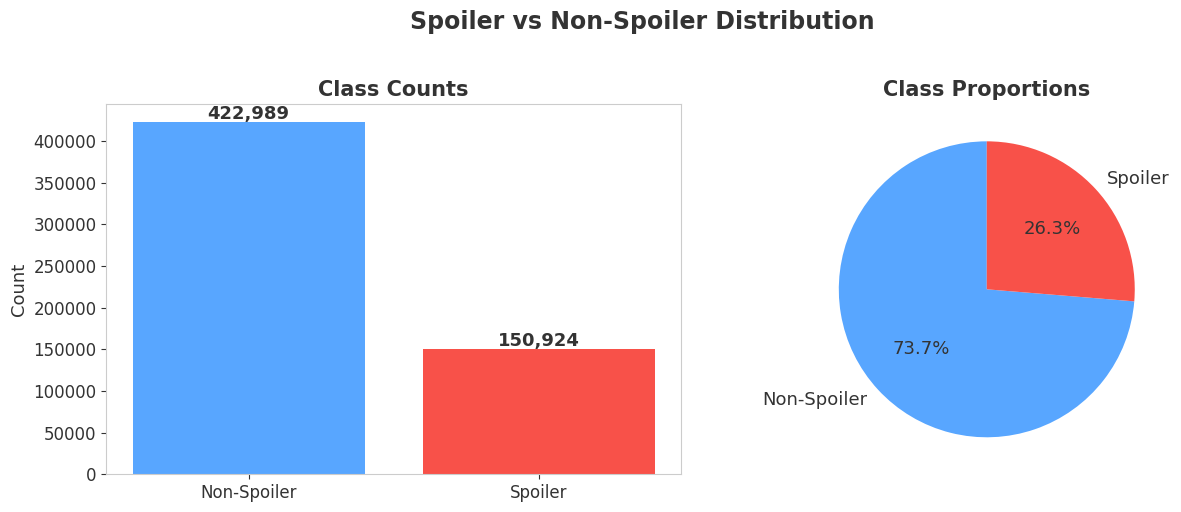

In [56]:
counts = df['label'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bars = axes[0].bar(LABEL_NAMES, counts.values,
                   color=[COLORS['non_spoiler'], COLORS['spoiler']], linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
                 f'{val:,}', ha='center', fontsize=13, fontweight='bold')

axes[0].set_ylabel('Count', fontsize=13)
axes[0].set_title('Class Counts', fontsize=15, fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=LABEL_NAMES, autopct='%1.1f%%',
    colors=[COLORS['non_spoiler'], COLORS['spoiler']],
    textprops={'fontsize': 13},
    wedgeprops={'linewidth': 1},
    startangle=90,
)

axes[1].set_title('Class Proportions', fontsize=15, fontweight='bold')

plt.suptitle('Spoiler vs Non-Spoiler Distribution', fontsize=17,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/DA/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Review Length Analysis

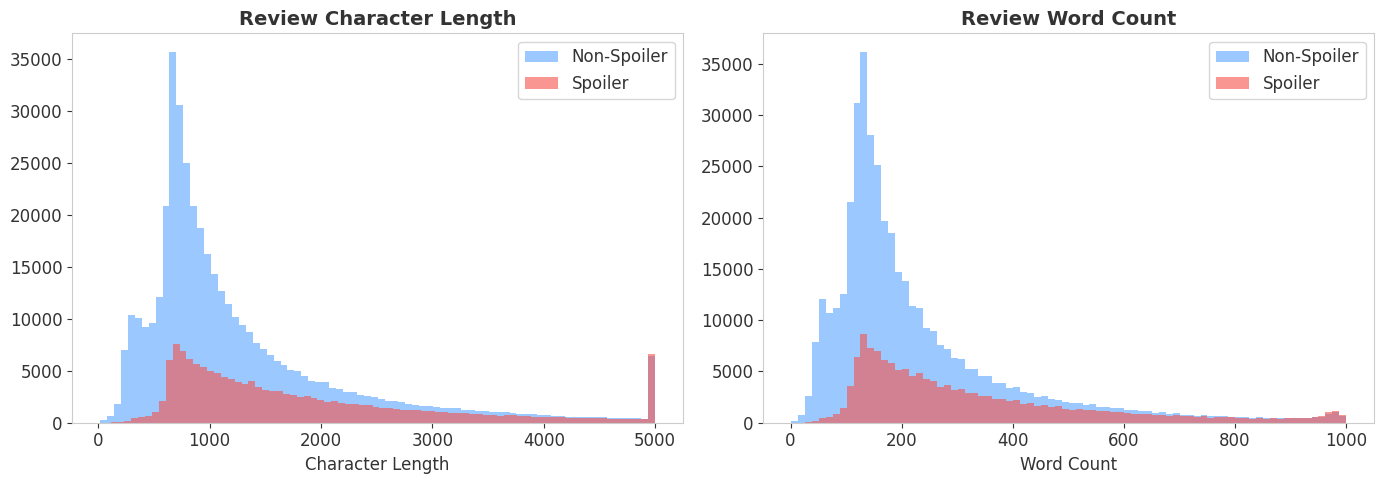

           review_length                                               \
                   count    mean     std   min    25%     50%     75%   
is_spoiler                                                              
False           422989.0  1308.2  1021.1  18.0  682.0   947.0  1575.0   
True            150924.0  1887.7  1283.8  50.0  920.0  1459.0  2456.0   

                    word_count                                                  
                max      count   mean    std  min    25%    50%    75%     max  
is_spoiler                                                                      
False       14963.0   422989.0  231.8  176.7  1.0  124.0  170.0  279.0  2675.0  
True        14302.0   150924.0  334.6  223.1  1.0  166.0  260.0  435.0  2562.0  


In [57]:
df['review_length'] = df['review_text'].str.len()
df['word_count'] = df['review_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, name, color in [(0, 'Non-Spoiler', COLORS['non_spoiler']), (1, 'Spoiler', COLORS['spoiler'])]:
    subset = df[df['label'] == label]
    axes[0].hist(subset['review_length'].clip(upper=5000), bins=80, alpha=0.6, color=color, label=name)
    axes[1].hist(subset['word_count'].clip(upper=1000), bins=80, alpha=0.6, color=color, label=name)

axes[0].set_xlabel('Character Length')
axes[0].set_title('Review Character Length', fontsize=14, fontweight='bold')
axes[0].legend()

axes[1].set_xlabel('Word Count')
axes[1].set_title('Review Word Count', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/DA/review_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('is_spoiler')[['review_length', 'word_count']].describe().round(1))

## 4 · Rating Distribution by Spoiler Status

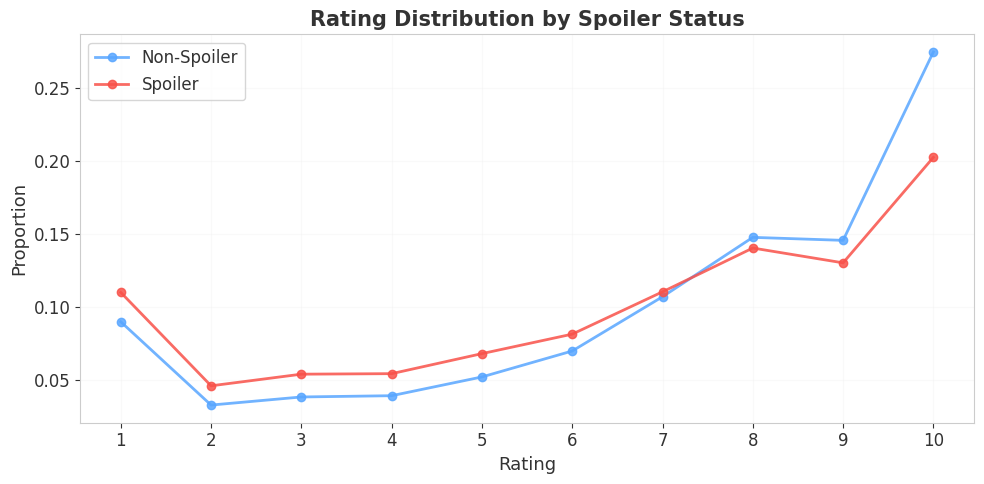

In [58]:
df['rating_num'] = pd.to_numeric(df['rating'], errors='coerce')

fig, ax = plt.subplots(figsize=(10, 5))
for label, name, color in [(0, 'Non-Spoiler', COLORS['non_spoiler']),
                            (1, 'Spoiler', COLORS['spoiler'])]:
    subset = df[df['label'] == label]
    rating_counts = subset['rating_num'].value_counts().sort_index()
    ax.plot(rating_counts.index, rating_counts.values / len(subset),
            marker='o', linewidth=2, color=color, label=name, alpha=0.85)

ax.set_xlabel('Rating', fontsize=13)
ax.set_ylabel('Proportion', fontsize=13)
ax.set_title('Rating Distribution by Spoiler Status', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xticks(range(1, 11))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/DA/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Word Clouds

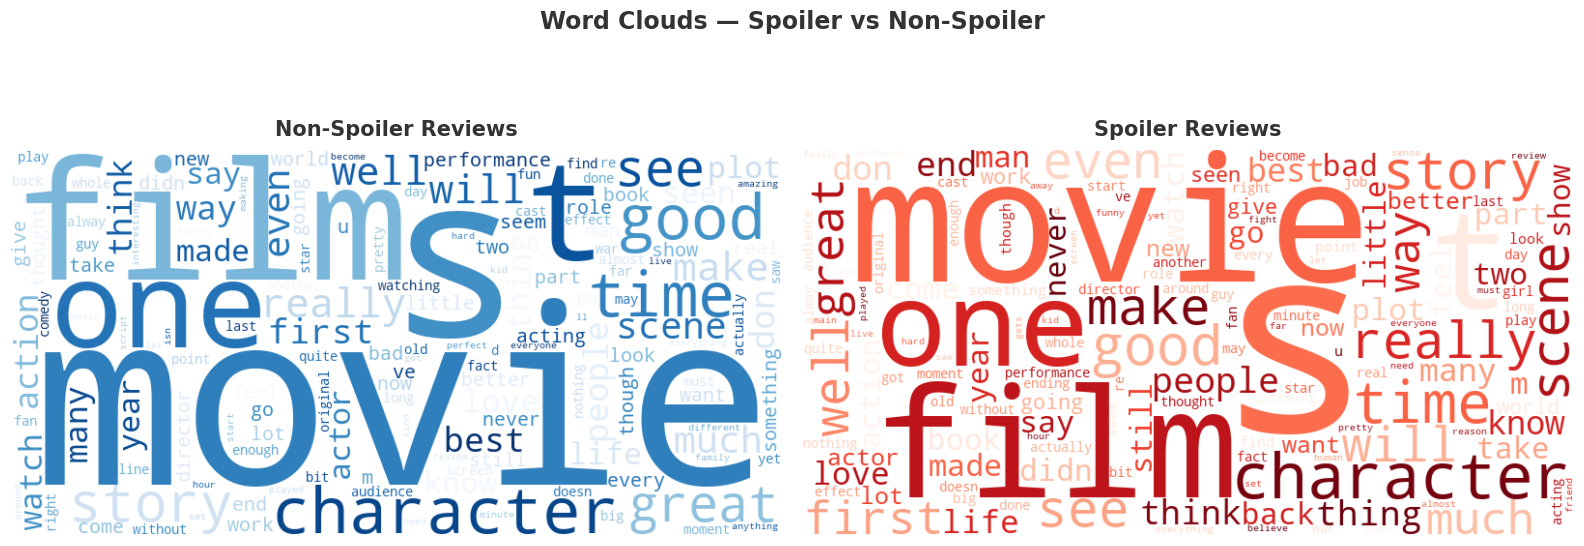

In [59]:
# Sample for word cloud speed
sample = df.sample(20000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (label, title, cmap) in enumerate([
    (0, 'Non-Spoiler Reviews', 'Blues'),
    (1, 'Spoiler Reviews', 'Reds'),
]):
    text = ' '.join(sample[sample['label'] == label]['review_text'].apply(clean_text).values)
    wc = WordCloud(width=800, height=400, max_words=150,
                   background_color='white', colormap=cmap,
                   collocations=False).generate(text)
                   
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(title, fontsize=15, fontweight='bold', pad=10)
    axes[idx].axis('off')

plt.suptitle('Word Clouds — Spoiler vs Non-Spoiler', fontsize=17,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/DA/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Top N-gram Analysis

In [63]:
def top_ngrams(texts, n=2, top_k=15):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10000)
    X = vec.fit_transform(texts)
    sums = X.sum(axis=0).A1
    names = vec.get_feature_names_out()
    top_idx = sums.argsort()[::-1][:top_k]
    return [(names[i], sums[i]) for i in top_idx]

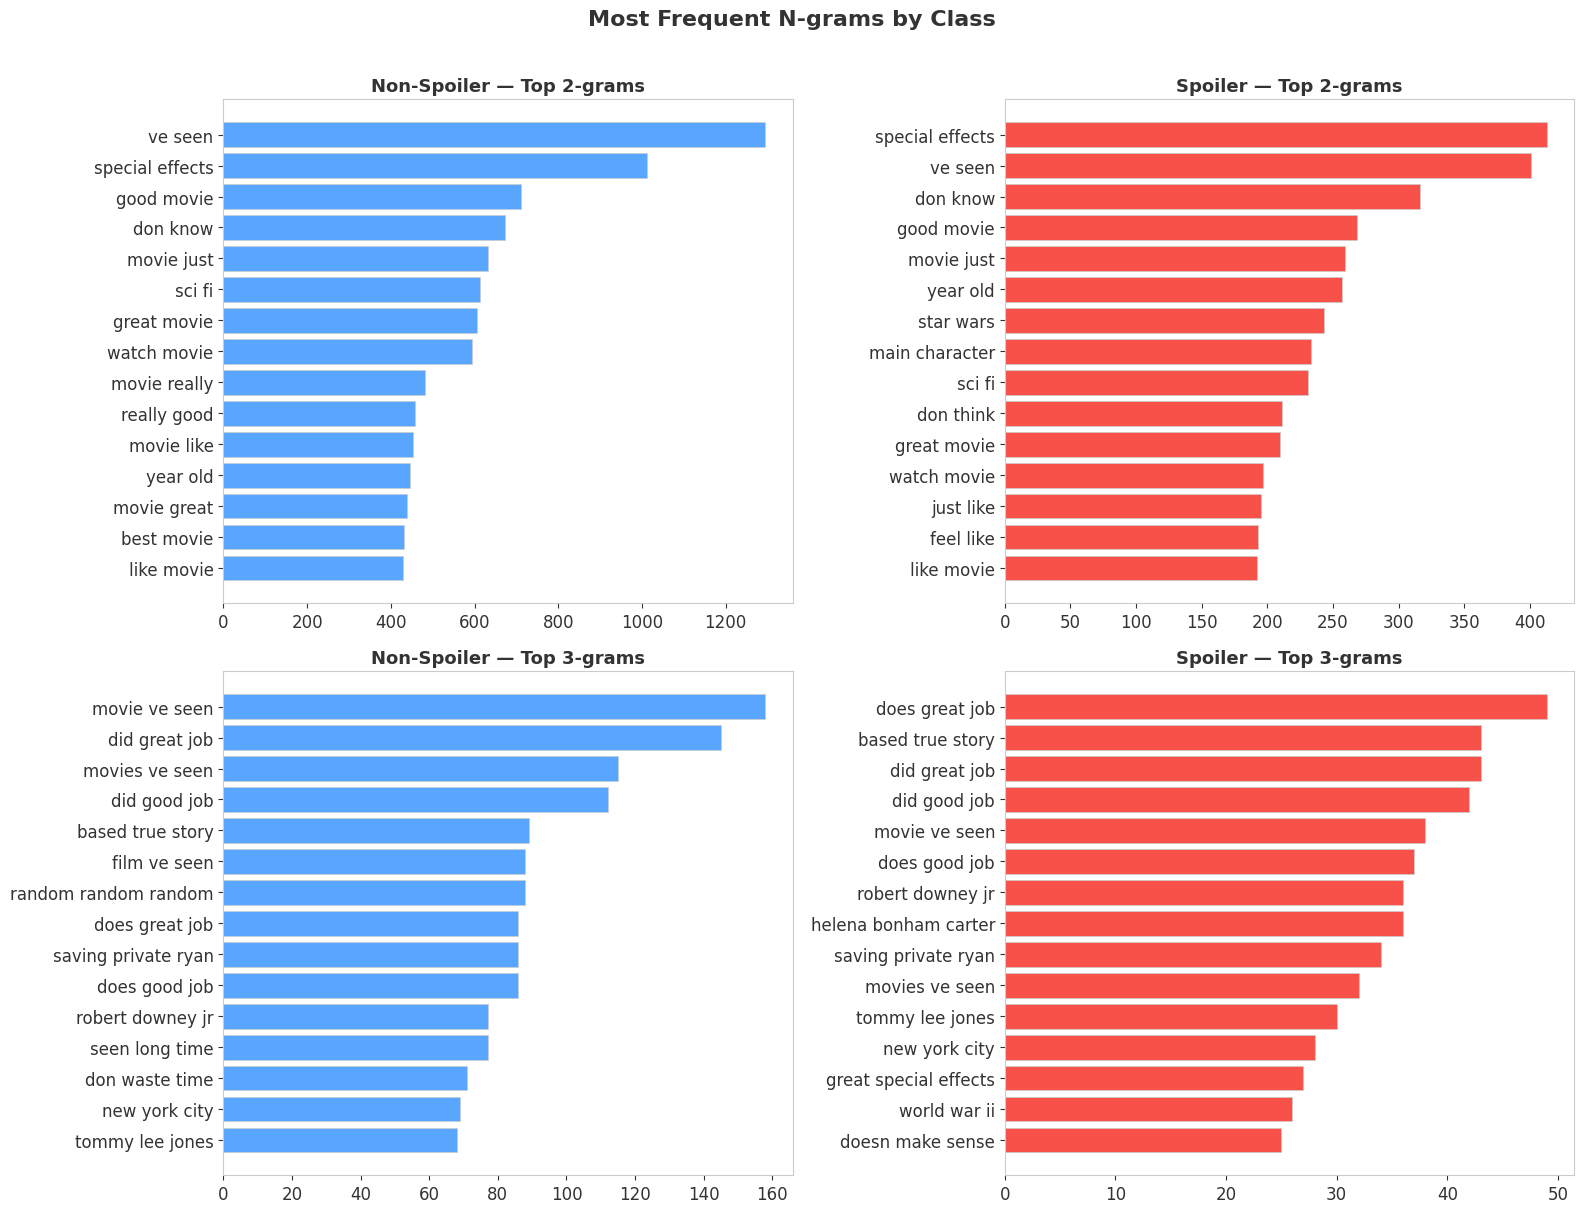

In [64]:
sample_clean = sample.copy()
sample_clean['clean'] = sample_clean['review_text'].apply(clean_text)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for row, n in enumerate([2, 3]):
    for col, (label, title, color) in enumerate([
        (0, 'Non-Spoiler', COLORS['non_spoiler']),
        (1, 'Spoiler', COLORS['spoiler']),
    ]):
        texts = sample_clean[sample_clean['label'] == label]['clean'].values
        ngrams = top_ngrams(texts, n=n, top_k=15)
        names_list = [g[0] for g in ngrams][::-1]
        counts_list = [g[1] for g in ngrams][::-1]
        axes[row][col].barh(names_list, counts_list, color=color,
                            edgecolor='#cccccc', linewidth=0.5)
        axes[row][col].set_title(f'{title} — Top {n}-grams',
                                 fontsize=13, fontweight='bold')

plt.suptitle('Most Frequent N-grams by Class', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/DA/ngrams.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Reviews per Movie

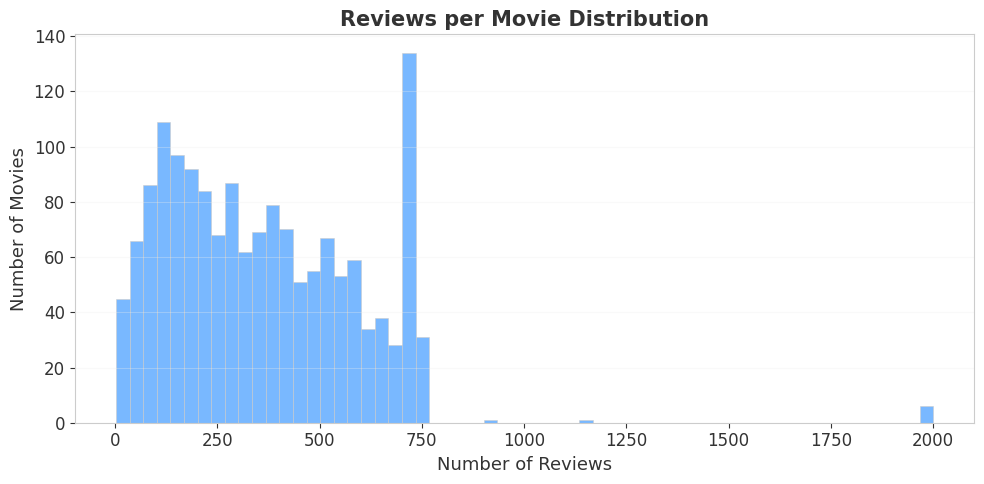

Mean reviews/movie : 365.1
Median             : 326
Max                : 4845


In [65]:
reviews_per_movie = df.groupby('movie_id').size()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(reviews_per_movie.clip(upper=2000), bins=60,
        color='#58a6ff', edgecolor='#cccccc', linewidth=0.5, alpha=0.8)
ax.set_xlabel('Number of Reviews', fontsize=13)
ax.set_ylabel('Number of Movies', fontsize=13)
ax.set_title('Reviews per Movie Distribution', fontsize=15, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/DA/reviews_per_movie.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean reviews/movie : {reviews_per_movie.mean():.1f}')
print(f'Median             : {reviews_per_movie.median():.0f}')
print(f'Max                : {reviews_per_movie.max()}')

## 8 · Genre Analysis

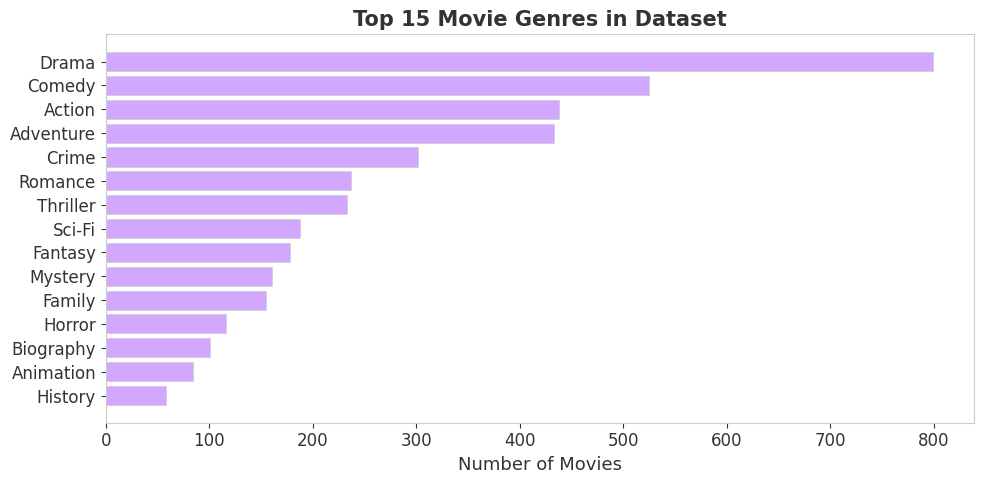

In [66]:
# Explode genres and count
genres = movies.explode('genre')
genre_counts = genres['genre'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
        color='#d2a8ff', edgecolor='#cccccc', linewidth=0.5)
ax.set_xlabel('Number of Movies', fontsize=13)
ax.set_title('Top 15 Movie Genres in Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/DA/genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Takeaways

- **Class imbalance:** ~26% spoiler vs 74% non-spoiler → need to account for this in model evaluation (F1 is more important than accuracy)
- **Spoiler reviews tend to be longer** — Possibly because they contain more plot details
- **Word/n-gram differences** provide signals that TF-IDF can capture
- The dataset covers diverse genres and a large number of movies (15 genres and 4008 movies)